# LigandEnsembles and SpinLigands

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rdkit import Chem
from rdkit.Chem import rdFMCS, AllChem
from rdkit.Chem.rdDistGeom import EmbedMultipleConfs

from rdkit.Chem.Draw import MolsToGridImage
import chilife as xl
import warnings
warnings.filterwarnings("ignore")

C:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dAdo = Chem.MolFromSmiles('[CH2]C1C(C(C(O1)N2C=NC3=C2N=CN=C3N)O)O')
dAdo = Chem.AddHs(dAdo)
EmbedMultipleConfs(dAdo, 500)

SAH = next(Chem.SDMolSupplier('SAH.sdf'))

mcs = rdFMCS.FindMCS((dAdo, SAH))



In [3]:
MCS = Chem.MolFromSmarts(mcs.smartsString)
match1 = dAdo.GetSubstructMatch(MCS)
match2 = SAH.GetSubstructMatch(MCS)

rmsds = []
for i in range(dAdo.GetNumConformers()):
    rmsds.append(AllChem.AlignMol(dAdo, SAH, atomMap=list(zip(match1, match2)), prbCid=i))

In [4]:
with Chem.SDWriter('dAdo.sdf') as w:
    for confid in range(dAdo.GetNumConformers()):
        w.write(dAdo, confId=confid)

In [5]:
min(rmsds)

0.22005410748676757

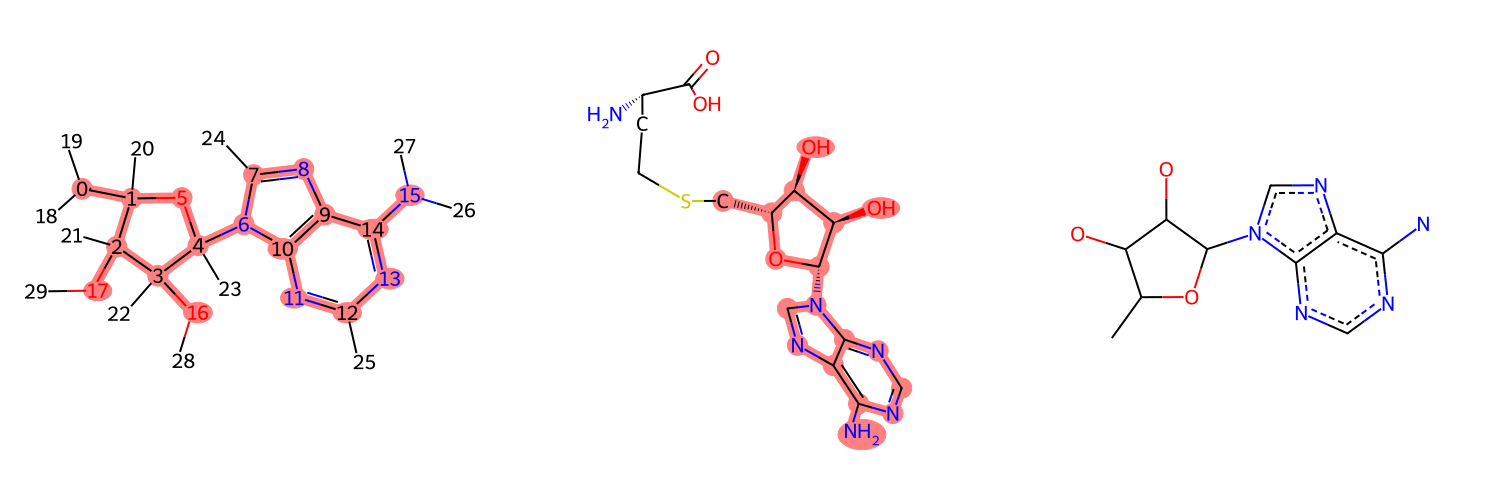

In [6]:
dAdo.RemoveAllConformers()
for atom in dAdo.GetAtoms():
    atom.SetProp('atomLabel', str(atom.GetIdx()))

MolsToGridImage((dAdo, SAH, MCS), subImgSize=[500, 500], highlightAtomLists=[match1, match2, []])


In [7]:
prot = xl.load_protein('7o1o.pdb').select_atoms("not resname SO4 PYR")

# With rotamer library method
LE1 = xl.SpinLigand.from_sdf('dAdo.sdf', 'RSM', 408, prot, alignment_method=None)

# With off-Rotamer sampling
LE2 = xl.SpinLigand.from_sdf('dAdo.sdf', 'RSS', 408, prot, alignment_method=None, sample=500)

xl.save(prot, LE1, LE2)

In [8]:
U, dE = xl.repack(prot, LE1, off_rotamer=True, repetitions=1000)

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:47<00:00, 21.24it/s]


In [9]:
xl.save(U, conect=True, frames=-1)

![labels](ligandens.png)